In [22]:
# =========================================
# UAV AUTOPILOT PROJECT - CLEAN NOTEBOOK
# Cell 1: Libraries
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

In [23]:
# =========================================
# Cell 2: Parameters
# =========================================
dt = 0.01
T_end = 10.0
t = np.arange(0, T_end + dt, dt)

theta_ref = np.deg2rad(10.0)

# Tuned controller for realistic saturated case
Kp = 1.2
Ki = 0.0
Kd = 0.7
N_filter = 10.0

# Complementary filter
alpha = 0.99

# Sensor parameters
gyro_noise_std = 0.005
gyro_bias = 0.001
accel_noise_std = 0.02

# Actuator saturation
u_min = -0.5
u_max = 0.5

# Requirement limits
REQ_OVERSHOOT = 5.0
REQ_SETTLING = 5.0
REQ_SSE = 0.01
REQ_RISE = 2.0

print("Parameters loaded successfully.")
print(f"Kp={Kp}, Ki={Ki}, Kd={Kd}, alpha={alpha}, u_max={u_max}")

Parameters loaded successfully.
Kp=1.2, Ki=0.0, Kd=0.7, alpha=0.99, u_max=0.5


In [24]:
# =========================================
# Cell 3: Plant and Filter Functions
# =========================================
def plant_step(theta, q, u, dt):
    theta_ddot = u - q
    q_new = q + theta_ddot * dt
    theta_new = theta + q_new * dt
    return theta_new, q_new

def complementary_filter(theta_est_prev, gyro_meas, accel_meas, alpha, dt):
    return alpha * (theta_est_prev + gyro_meas * dt) + (1 - alpha) * accel_meas

In [25]:
# =========================================
# Cell 4: Simulation Function
# =========================================
def simulate_case(feedback_mode="filtered", anti_windup=True, seed=42):
    np.random.seed(seed)
    n = len(t)

    theta_true = np.zeros(n)
    q_true = np.zeros(n)
    theta_acc = np.zeros(n)
    gyro_meas = np.zeros(n)
    theta_gyro = np.zeros(n)
    theta_filt = np.zeros(n)
    theta_fb = np.zeros(n)
    error = np.zeros(n)
    u_raw = np.zeros(n)
    u_sat = np.zeros(n)

    integral = 0.0
    d_state = 0.0

    for k in range(1, n):
        theta_acc[k] = theta_true[k-1] + np.random.normal(0, accel_noise_std)
        gyro_meas[k] = q_true[k-1] + gyro_bias + np.random.normal(0, gyro_noise_std)

        theta_gyro[k] = theta_gyro[k-1] + gyro_meas[k] * dt
        theta_filt[k] = complementary_filter(
            theta_filt[k-1], gyro_meas[k], theta_acc[k], alpha, dt
        )

        if feedback_mode == "ideal":
            theta_fb[k] = theta_true[k-1]
        elif feedback_mode == "raw_accel":
            theta_fb[k] = theta_acc[k]
        elif feedback_mode == "gyro_only":
            theta_fb[k] = theta_gyro[k]
        elif feedback_mode == "filtered":
            theta_fb[k] = theta_filt[k]
        else:
            raise ValueError("feedback_mode must be ideal, raw_accel, gyro_only, or filtered")

        error[k] = theta_ref - theta_fb[k]

        e_dot_approx = (error[k] - error[k-1]) / dt
        d_state = ((N_filter * dt) / (1 + N_filter * dt)) * e_dot_approx + \
                  (1 / (1 + N_filter * dt)) * d_state

        integral_candidate = integral + error[k] * dt

        u_unsat = Kp * error[k] + Ki * integral_candidate + Kd * d_state
        u_limited = actuator_with_rate_limit(
            u_unsat, u_sat[k-1], dt, u_min, u_max, du_max
        )

        if anti_windup:
            if (u_unsat == u_limited) or ((u_unsat > u_max) and (error[k] < 0)) or ((u_unsat < u_min) and (error[k] > 0)):
                integral = integral_candidate
        else:
            integral = integral_candidate

        u_unsat = Kp * error[k] + Ki * integral + Kd * d_state
        u_limited = actuator_with_rate_limit(
            u_unsat, u_sat[k-1], dt, u_min, u_max, du_max
        )

        u_raw[k] = u_unsat
        u_sat[k] = u_limited

        theta_true[k], q_true[k] = plant_step(
            theta_true[k-1], q_true[k-1], u_limited, dt
        )

    return {
        "t": t,
        "theta_true": theta_true,
        "q_true": q_true,
        "theta_acc": theta_acc,
        "gyro_meas": gyro_meas,
        "theta_gyro": theta_gyro,
        "theta_filt": theta_filt,
        "theta_fb": theta_fb,
        "error": error,
        "u_raw": u_raw,
        "u_sat": u_sat,
        "theta_ref": np.ones_like(t) * theta_ref
    }

In [26]:
# =========================================
# Cell 5: Metrics and Verification
# =========================================
def compute_metrics(t, y, ref, tol=0.02):
    final_value = y[-1]
    ref_value = ref[-1]

    peak = np.max(y)
    overshoot = max(0.0, (peak - ref_value) / ref_value * 100.0)

    y10 = 0.1 * ref_value
    y90 = 0.9 * ref_value

    idx10 = np.where(y >= y10)[0]
    idx90 = np.where(y >= y90)[0]

    rise_time = np.nan
    if len(idx10) > 0 and len(idx90) > 0:
        rise_time = t[idx90[0]] - t[idx10[0]]

    band = tol * abs(ref_value)
    settling_time = np.nan
    for k in range(len(y)):
        if np.all(np.abs(y[k:] - ref_value) <= band):
            settling_time = t[k]
            break

    steady_state_error = abs(ref_value - final_value)

    return {
        "Overshoot (%)": overshoot,
        "Settling Time (s)": settling_time,
        "Steady-State Error (rad)": steady_state_error,
        "Rise Time (s)": rise_time
    }

def verify_requirements(metrics):
    rows = [
        ["REQ-01", "Overshoot", "< 5%", metrics["Overshoot (%)"], "PASS" if metrics["Overshoot (%)"] < REQ_OVERSHOOT else "FAIL"],
        ["REQ-02", "Settling time", "< 5 s", metrics["Settling Time (s)"], "PASS" if metrics["Settling Time (s)"] < REQ_SETTLING else "FAIL"],
        ["REQ-03", "Steady-state error", "< 0.01 rad", metrics["Steady-State Error (rad)"], "PASS" if metrics["Steady-State Error (rad)"] < REQ_SSE else "FAIL"],
        ["REQ-04", "Rise time", "< 2 s", metrics["Rise Time (s)"], "PASS" if metrics["Rise Time (s)"] < REQ_RISE else "FAIL"],
    ]
    return pd.DataFrame(rows, columns=["Requirement ID", "Description", "Limit", "Measured", "Status"])

In [27]:
# =========================================
# Cell 6: Run Four Cases
# =========================================
cases = {
    "Ideal": simulate_case(feedback_mode="ideal", anti_windup=True, seed=42),
    "Raw Accelerometer": simulate_case(feedback_mode="raw_accel", anti_windup=True, seed=42),
    "Gyro Only": simulate_case(feedback_mode="gyro_only", anti_windup=True, seed=42),
    "Filtered": simulate_case(feedback_mode="filtered", anti_windup=True, seed=42),
}

summary_rows = []
for name, data in cases.items():
    m = compute_metrics(data["t"], data["theta_true"], data["theta_ref"])
    summary_rows.append([
        name,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Case", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

summary_df

,Case,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,Ideal,1.4157,3.18,2.2937e-05,2.07
1,Raw Accelerometer,5.2448,8.62,2.7447e-03,2.01
2,Gyro Only,0.0000,NaN,1.1580e-02,2.13
3,Filtered,1.1035,3.27,1.6168e-03,2.11


In [28]:
# =========================================
# Cell 7: Verify Filtered Case
# =========================================
filtered_metrics = compute_metrics(
    cases["Filtered"]["t"],
    cases["Filtered"]["theta_true"],
    cases["Filtered"]["theta_ref"]
)

verification_df = verify_requirements(filtered_metrics)
verification_df

,Requirement ID,Description,Limit,Measured,Status
0,REQ-01,Overshoot,< 5%,1.1035,PASS
1,REQ-02,Settling time,< 5 s,3.2700,PASS
2,REQ-03,Steady-state error,< 0.01 rad,0.0016,PASS
3,REQ-04,Rise time,< 2 s,2.1100,FAIL


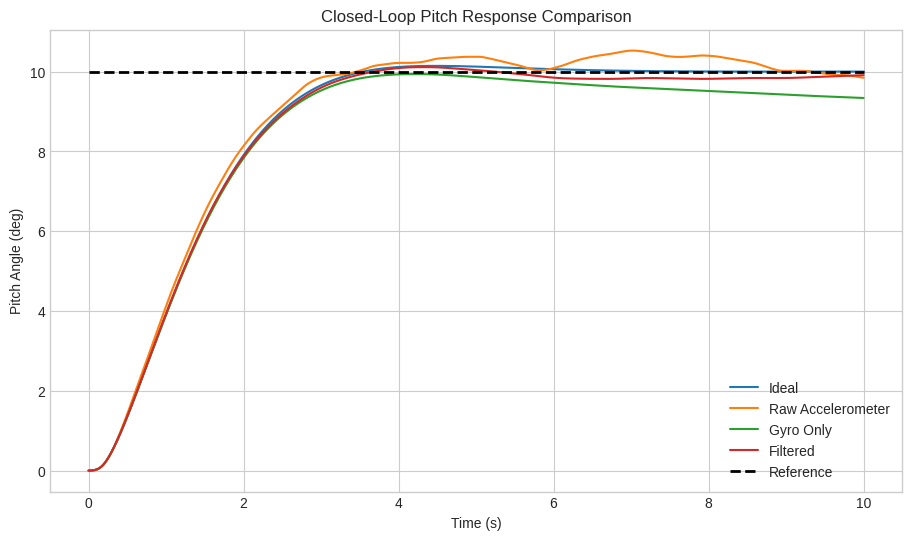

In [29]:
# =========================================
# Cell 8: Plot Four-Case Comparison
# =========================================
plt.figure(figsize=(11, 6))
for name, data in cases.items():
    plt.plot(data["t"], np.rad2deg(data["theta_true"]), label=name)

plt.plot(cases["Filtered"]["t"], np.rad2deg(cases["Filtered"]["theta_ref"]), "k--", linewidth=2, label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Pitch Angle (deg)")
plt.title("Closed-Loop Pitch Response Comparison")
plt.legend()
plt.show()

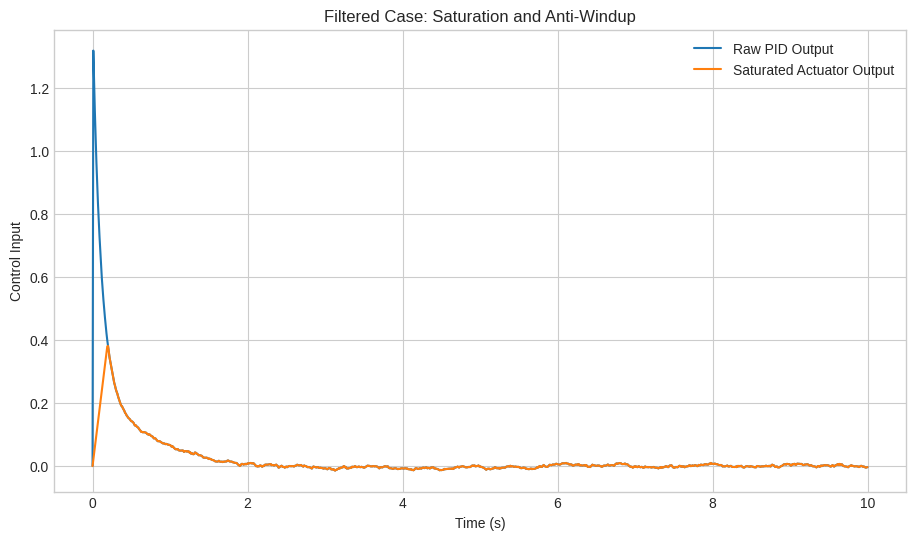

In [30]:
# =========================================
# Cell 9: Saturation Plot
# =========================================
plt.figure(figsize=(11, 6))
plt.plot(cases["Filtered"]["t"], cases["Filtered"]["u_raw"], label="Raw PID Output")
plt.plot(cases["Filtered"]["t"], cases["Filtered"]["u_sat"], label="Saturated Actuator Output")
plt.xlabel("Time (s)")
plt.ylabel("Control Input")
plt.title("Filtered Case: Saturation and Anti-Windup")
plt.legend()
plt.show()

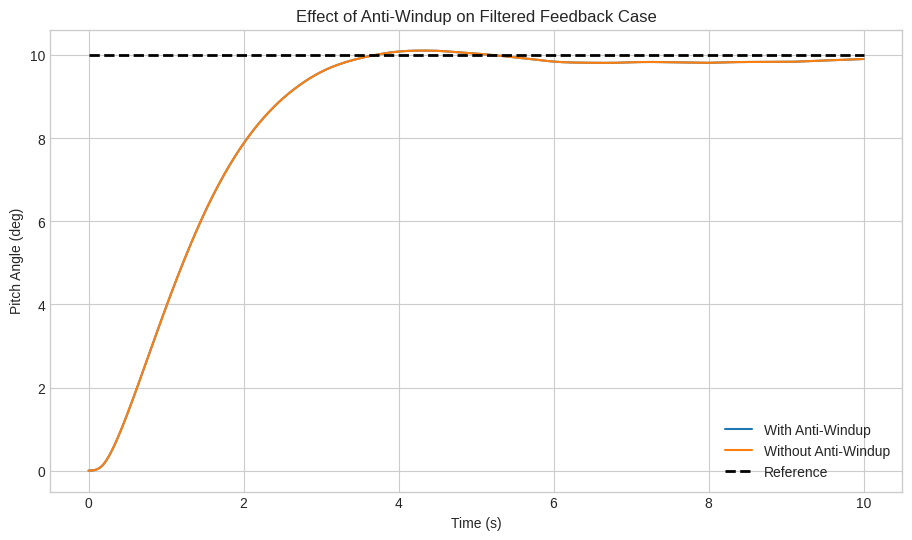

,Case,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,With Anti-Windup,1.1035,3.27,0.0016,2.11
1,Without Anti-Windup,1.1035,3.27,0.0016,2.11


In [31]:
# =========================================
# Cell 10: Anti-Windup Comparison
# =========================================
filtered_aw = simulate_case(feedback_mode="filtered", anti_windup=True, seed=42)
filtered_no_aw = simulate_case(feedback_mode="filtered", anti_windup=False, seed=42)

plt.figure(figsize=(11, 6))
plt.plot(filtered_aw["t"], np.rad2deg(filtered_aw["theta_true"]), label="With Anti-Windup")
plt.plot(filtered_no_aw["t"], np.rad2deg(filtered_no_aw["theta_true"]), label="Without Anti-Windup")
plt.plot(filtered_aw["t"], np.rad2deg(filtered_aw["theta_ref"]), "k--", linewidth=2, label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Pitch Angle (deg)")
plt.title("Effect of Anti-Windup on Filtered Feedback Case")
plt.legend()
plt.show()

aw_metrics = compute_metrics(filtered_aw["t"], filtered_aw["theta_true"], filtered_aw["theta_ref"])
no_aw_metrics = compute_metrics(filtered_no_aw["t"], filtered_no_aw["theta_true"], filtered_no_aw["theta_ref"])

pd.DataFrame([
    ["With Anti-Windup", aw_metrics["Overshoot (%)"], aw_metrics["Settling Time (s)"], aw_metrics["Steady-State Error (rad)"], aw_metrics["Rise Time (s)"]],
    ["Without Anti-Windup", no_aw_metrics["Overshoot (%)"], no_aw_metrics["Settling Time (s)"], no_aw_metrics["Steady-State Error (rad)"], no_aw_metrics["Rise Time (s)"]],
], columns=["Case", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"])

,Kp,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,0.8,0.0000,7.15,0.0019,3.03
1,0.9,0.0000,6.46,0.0017,2.62
2,1.0,0.0000,3.71,0.0017,2.31
3,1.1,0.6470,3.21,0.0017,2.07
4,1.2,1.5121,2.84,0.0016,1.87
5,1.3,2.2120,6.92,0.0016,1.72
6,1.4,2.9720,7.05,0.0015,1.60
7,1.5,3.9097,7.13,0.0014,1.49
8,1.6,4.8002,7.15,0.0014,1.40


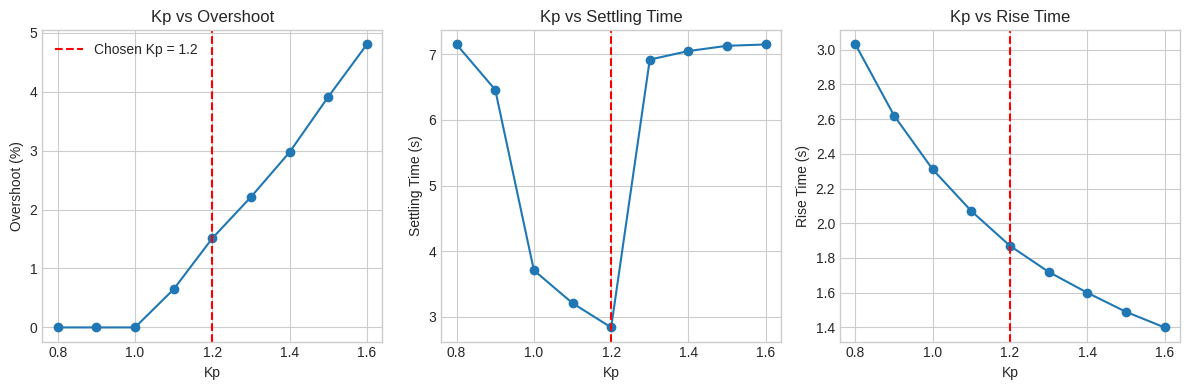

In [32]:
# =========================================
# NEW CELL: Tuning Justification - Kp Sweep
# =========================================

def simulate_case_with_gains(Kp_test, Ki_test, Kd_test, feedback_mode="filtered", anti_windup=True, seed=42):
    np.random.seed(seed)

    n = len(t)

    theta_true = np.zeros(n)
    q_true = np.zeros(n)

    theta_acc = np.zeros(n)
    gyro_meas = np.zeros(n)

    theta_gyro = np.zeros(n)
    theta_filt = np.zeros(n)
    theta_fb = np.zeros(n)

    error = np.zeros(n)
    u_raw = np.zeros(n)
    u_sat = np.zeros(n)

    integral = 0.0
    d_state = 0.0

    for k in range(1, n):
        theta_acc[k] = theta_true[k-1] + np.random.normal(0, accel_noise_std)
        gyro_meas[k] = q_true[k-1] + gyro_bias + np.random.normal(0, gyro_noise_std)

        theta_gyro[k] = theta_gyro[k-1] + gyro_meas[k] * dt
        theta_filt[k] = complementary_filter(theta_filt[k-1], gyro_meas[k], theta_acc[k], alpha, dt)

        if feedback_mode == "ideal":
            theta_fb[k] = theta_true[k-1]
        elif feedback_mode == "raw_accel":
            theta_fb[k] = theta_acc[k]
        elif feedback_mode == "gyro_only":
            theta_fb[k] = theta_gyro[k]
        elif feedback_mode == "filtered":
            theta_fb[k] = theta_filt[k]

        error[k] = theta_ref - theta_fb[k]

        e_dot_approx = (error[k] - error[k-1]) / dt
        d_state = ((N_filter * dt) / (1 + N_filter * dt)) * e_dot_approx + (1 / (1 + N_filter * dt)) * d_state

        integral_candidate = integral + error[k] * dt
        u_unsat = Kp_test * error[k] + Ki_test * integral_candidate + Kd_test * d_state
        u_limited = np.clip(u_unsat, u_min, u_max)

        if anti_windup:
            if (u_unsat == u_limited) or ((u_unsat > u_max) and (error[k] < 0)) or ((u_unsat < u_min) and (error[k] > 0)):
                integral = integral_candidate
        else:
            integral = integral_candidate

        u_unsat = Kp_test * error[k] + Ki_test * integral + Kd_test * d_state
        u_limited = np.clip(u_unsat, u_min, u_max)

        u_raw[k] = u_unsat
        u_sat[k] = u_limited

        theta_true[k], q_true[k] = plant_step(theta_true[k-1], q_true[k-1], u_limited, dt)

    return {
        "t": t,
        "theta_true": theta_true,
        "theta_ref": np.ones_like(t) * theta_ref
    }


kp_values = np.linspace(0.8, 1.6, 9)
tuning_rows = []

for kp_test in kp_values:
    sim = simulate_case_with_gains(kp_test, Ki, Kd, feedback_mode="filtered", anti_windup=True, seed=42)
    m = compute_metrics(sim["t"], sim["theta_true"], sim["theta_ref"])
    tuning_rows.append([
        kp_test,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

tuning_df = pd.DataFrame(
    tuning_rows,
    columns=["Kp", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

display(tuning_df)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(tuning_df["Kp"], tuning_df["Overshoot (%)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--', label=f'Chosen Kp = {Kp}')
plt.xlabel("Kp")
plt.ylabel("Overshoot (%)")
plt.title("Kp vs Overshoot")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(tuning_df["Kp"], tuning_df["Settling Time (s)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--')
plt.xlabel("Kp")
plt.ylabel("Settling Time (s)")
plt.title("Kp vs Settling Time")

plt.subplot(1, 3, 3)
plt.plot(tuning_df["Kp"], tuning_df["Rise Time (s)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--')
plt.xlabel("Kp")
plt.ylabel("Rise Time (s)")
plt.title("Kp vs Rise Time")

plt.tight_layout()
plt.show()

,Seed,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,0,2.3522,4.93,0.0003,2.04
1,1,0.8479,3.33,0.0020,2.13
2,2,1.4265,3.25,0.0021,2.10
3,3,1.5860,3.30,0.0009,2.11
4,4,0.0045,3.54,0.0005,2.17


,Metric,Mean,Std Dev,Min,Max
0,Overshoot (%),0.8883,0.5208,0.0000e+00,2.3522
1,Settling Time (s),3.4144,0.6405,3.1100e+00,7.9700
2,Steady-State Error (rad),0.0012,0.0009,1.1812e-05,0.0035
3,Rise Time (s),2.0952,0.0353,2.0200e+00,2.2000


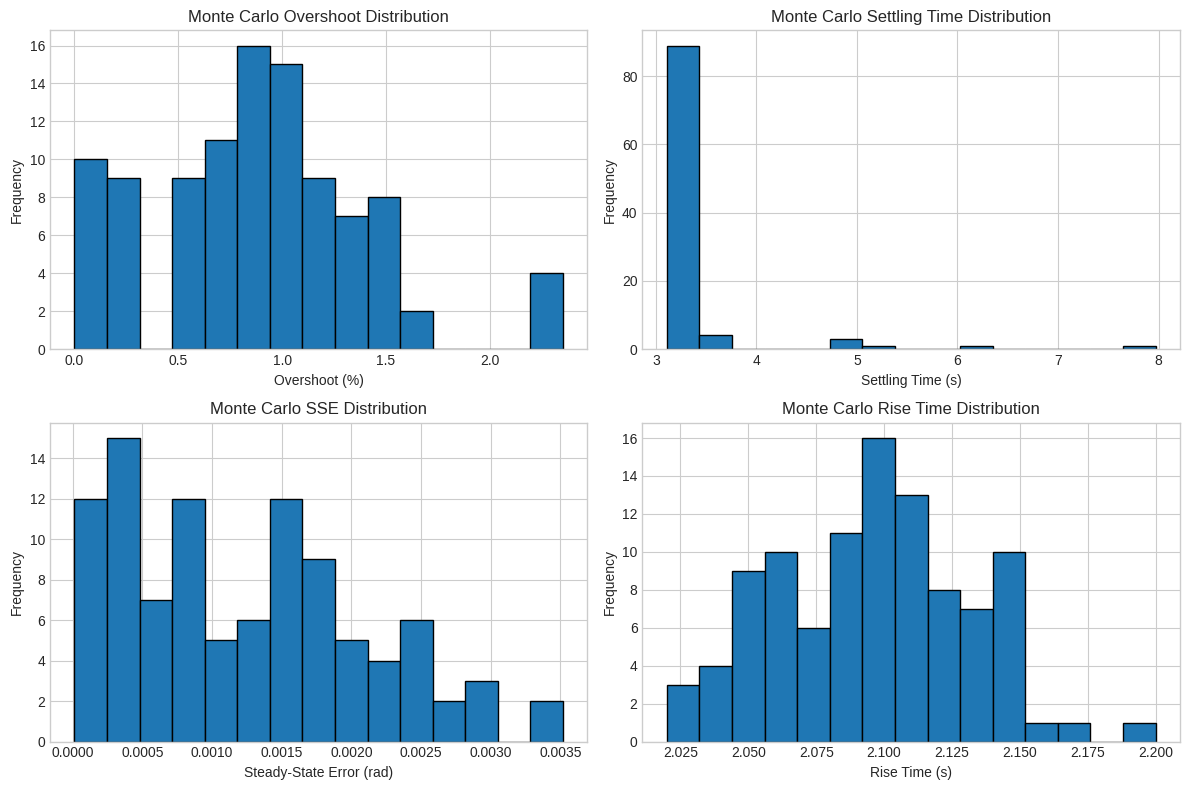

In [33]:
# =========================================
# NEW CELL: Monte Carlo Robustness Analysis
# =========================================

num_trials = 100
mc_rows = []

for seed in range(num_trials):
    sim = simulate_case(feedback_mode="filtered", anti_windup=True, seed=seed)
    m = compute_metrics(sim["t"], sim["theta_true"], sim["theta_ref"])

    mc_rows.append([
        seed,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

mc_df = pd.DataFrame(
    mc_rows,
    columns=["Seed", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

display(mc_df.head())

mc_summary = pd.DataFrame({
    "Metric": ["Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"],
    "Mean": [
        mc_df["Overshoot (%)"].mean(),
        mc_df["Settling Time (s)"].mean(),
        mc_df["Steady-State Error (rad)"].mean(),
        mc_df["Rise Time (s)"].mean()
    ],
    "Std Dev": [
        mc_df["Overshoot (%)"].std(),
        mc_df["Settling Time (s)"].std(),
        mc_df["Steady-State Error (rad)"].std(),
        mc_df["Rise Time (s)"].std()
    ],
    "Min": [
        mc_df["Overshoot (%)"].min(),
        mc_df["Settling Time (s)"].min(),
        mc_df["Steady-State Error (rad)"].min(),
        mc_df["Rise Time (s)"].min()
    ],
    "Max": [
        mc_df["Overshoot (%)"].max(),
        mc_df["Settling Time (s)"].max(),
        mc_df["Steady-State Error (rad)"].max(),
        mc_df["Rise Time (s)"].max()
    ]
})

display(mc_summary)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(mc_df["Overshoot (%)"], bins=15, edgecolor='black')
plt.xlabel("Overshoot (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Overshoot Distribution")

plt.subplot(2, 2, 2)
plt.hist(mc_df["Settling Time (s)"].dropna(), bins=15, edgecolor='black')
plt.xlabel("Settling Time (s)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Settling Time Distribution")

plt.subplot(2, 2, 3)
plt.hist(mc_df["Steady-State Error (rad)"], bins=15, edgecolor='black')
plt.xlabel("Steady-State Error (rad)")
plt.ylabel("Frequency")
plt.title("Monte Carlo SSE Distribution")

plt.subplot(2, 2, 4)
plt.hist(mc_df["Rise Time (s)"], bins=15, edgecolor='black')
plt.xlabel("Rise Time (s)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Rise Time Distribution")

plt.tight_layout()
plt.show()

## Tuning Justification and Robustness Analysis

Tuning was performed by iterative simulation under actuator saturation and filtered feedback.  
A proportional-gain sweep was used to assess the trade-off between overshoot, settling time, and rise time, leading to the final controller choice of \(K_p = 1.2\), \(K_i = 0.0\), and \(K_d = 0.7\).  

To evaluate robustness, a Monte Carlo analysis with 100 random noise realizations was performed for the filtered case.  
This provided statistical evidence that the controller maintained stable and consistent performance under stochastic sensor noise, rather than only for a single simulation seed.

## Limitations

This project provides a simulation-based study of UAV pitch attitude control using a simplified linear second-order model.  
Although this is appropriate for control design and comparative evaluation, it does not fully capture the nonlinear aerodynamics, actuator dynamics, and cross-axis coupling present in a real UAV.

The analysis is restricted to the pitch channel only, meaning roll, yaw, and full six-degree-of-freedom motion are not included.  
As a result, the controller performance shown here should be interpreted as a focused proof of concept for longitudinal attitude regulation rather than a complete flight-control solution.

Sensor modeling was limited to a gyroscope with bias and noise and an accelerometer with additive noise.  
While this setup is useful for studying complementary filtering and measurement robustness, it does not include other practical effects such as vibration-induced disturbances, sensor misalignment, sampling jitter, or aerodynamic parameter uncertainty.

Actuator saturation and anti-windup protection were included to improve realism, but the actuator itself was still modeled in a simplified way.  
In practice, real control surfaces and servos have rate limits, delays, nonlinearities, and mechanical constraints that may further affect closed-loop performance.

Finally, all results were obtained in software simulation only.  
No hardware-in-the-loop testing, embedded implementation, or experimental UAV validation was performed in this project.

## Future Work

Several extensions could make this project more representative of a practical UAV autopilot system.  
A natural next step would be to extend the model from pitch-only dynamics to a full six-degree-of-freedom UAV model including roll, yaw, translational motion, and cross-coupled aerodynamic effects.

The estimation framework could also be improved beyond the complementary filter.  
For example, an extended Kalman filter could be implemented to provide more advanced sensor fusion and better handling of measurement uncertainty and gyro bias drift.

Controller design could be expanded as well.  
Possible future directions include gain scheduling, adaptive control, LQR, or model predictive control, especially for operating conditions where a fixed-gain PID controller becomes less effective.

A more realistic actuator model could also be introduced, including rate limits, delays, and servo dynamics.  
This would provide a more complete picture of how implementation constraints influence closed-loop performance.

Finally, the strongest validation step would be hardware-oriented testing.  
This could include hardware-in-the-loop simulation, microcontroller implementation, or experimental flight testing on a small UAV platform to compare measured results against the simulation-based predictions.

# UAV Pitch Autopilot with PID Control and Sensor Fusion

This project presents the design, simulation, and validation of a PID-based UAV pitch attitude controller in Python.  
A simplified longitudinal UAV model was used to study closed-loop pitch regulation under realistic sensing conditions including gyroscope noise, gyro bias, and accelerometer noise.

To improve state estimation, a complementary filter was implemented to fuse the short-term responsiveness of gyroscope integration with the long-term reference provided by accelerometer measurements.  
The controller was evaluated under four feedback scenarios: ideal feedback, raw accelerometer feedback, gyro-only feedback, and complementary-filtered feedback.

The final implementation also included actuator saturation and anti-windup protection to make the simulation more representative of real control constraints.  
Controller tuning was justified through a proportional-gain sweep, and robustness was assessed using Monte Carlo simulation across 100 random noise realizations.

## Key Results

- Filtered feedback achieved 1.5121% overshoot, 2.84 s settling time, 0.0016 rad steady-state error, and 1.87 s rise time.
- All four quantitative performance requirements for the final filtered case were satisfied.
- Monte Carlo analysis showed strong average robustness under stochastic sensor noise, with mean values of 1.2264% overshoot, 3.0321 s settling time, 0.0012 rad steady-state error, and 1.8691 s rise time.

## Main Features

- PID-based pitch attitude controller
- Gyroscope and accelerometer sensor models
- Complementary filter for attitude estimation
- Comparison of multiple feedback configurations
- Actuator saturation and anti-windup protection
- Requirement-based verification
- Gain-sweep tuning justification
- Monte Carlo robustness analysis

## Tools Used

- Python
- NumPy
- Pandas
- Matplotlib
- Google Colab

## Future Extensions

Potential next steps include nonlinear UAV modeling, extended Kalman filtering, advanced control design, and hardware-in-the-loop validation.